Original Shape: (3653, 48)
Features used: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'temperature_2m', 'relative_humidity_2m', 'apparent_temperature', 'rain', 'pressure_msl', 'wind_speed_10m', 'dew_point_2m', 'weather_code', 'surface_pressure', 'soil_temperature_0_to_7cm', 'soil_moisture_0_to_7cm', 'wind_gusts_10m', 'wind_direction_10m', 'cloud_cover', 'precipitation', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'cloud_cover_high', 'cloud_cover_low', 'cloud_cover_mid', 'soil_temperature_7_to_28cm', 'wind_speed_100m', 'wind_direction_100m', 'is_day', 'total_column_integrated_water_vapour', 'wet_bulb_temperature_2m', 'direct_radiation', 'direct_radiation_instant', 'hour', 'weekday', 'is_weekend']
Train shape: (2922, 43)
Test shape: (731, 43)

=== Model Performance ===
MAE (Mean Absolute Error): 123.5
R² Score: -0.109

Top 10 Important Features:
                       Feature  Importance
20            surface_pressure    0.

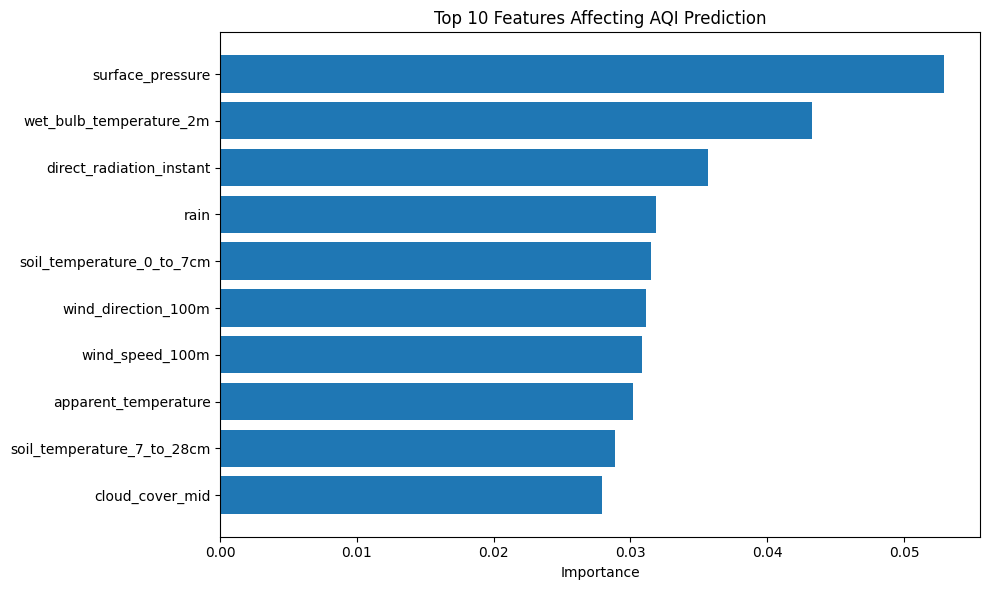

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# Load merged data
merged = pd.read_csv("kolkata_aqi_merged_final.csv")
merged['datetime'] = pd.to_datetime(merged['datetime'])

print("Original Shape:", merged.shape)

# ====================== FEATURE ENGINEERING ======================

# Drop non-useful columns
drop_cols = ['City', 'AQI_Bucket', 'datetime']  # Keep AQI as target
features = [col for col in merged.columns if col not in drop_cols + ['AQI']]

X = merged[features].copy()
y = merged['AQI']

# Handle categorical column
X = pd.get_dummies(X, columns=['traffic_level'], drop_first=True)

print("Features used:", X.columns.tolist())

# ====================== TRAIN-TEST SPLIT ======================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ====================== TRAIN XGBOOST MODEL ======================

model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

# ====================== EVALUATE ======================

y_pred = model.predict(X_test)

print("\n=== Model Performance ===")
print("MAE (Mean Absolute Error):", round(mean_absolute_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 3))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][:10], importance['Importance'][:10])
plt.title('Top 10 Features Affecting AQI Prediction')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()